# Run experiments
Use the `run_experiment` function or command-line program `python -m experiment "{paramdict}"` to train a model with the provided parameters. Output statistics are written to a CSV file in `stats/` directory. This notebook defines all experiments run in the study. The terms `488`, `cy3`, `cy5`, and `txr` refer to fluorescent dyes corresponding to the respective bacteria species. 

In [1]:
import sys
import numpy as np

sys.path.append("./scripts")
import experiment as experiment
import imgtool as t
import pandas as pd

c:\Users\silve\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


c:\Users\silve\Documents\210\./scripts\imgtool.py


## Vary ResNet Model

In [2]:
desc = "Resnet-vary-model"
epochs = 300
exps_resnet = []

for seed in [32, 42, 62, 72, 82]:
    for ptrain in [True, False]:
        for mtype in [
            "resnet18",
            "resnet26",
            "resnet34",
            "resnet50",
            "resnet152",
            "resnet200",
        ]:
            lr = 0.0005 if mtype == "resnet34" else 0.001
            params = {
                "exp_desc": desc,
                "model_id": "timm",
                "model_params": {"variant": mtype, "pretrained": ptrain},
                "n_epochs": epochs,
                "random_seed": seed,
                "learning_rate": lr,
            }
            exps_resnet.append(params)

    for mtype in ["resnet14", "resnet20", "resnet32"]:
        params = {
            "exp_desc": desc,
            "model_id": "resnet_CIFAR10",
            "model_params": {"variant": mtype},
            "n_epochs": epochs,
            "random_seed": seed,
        }
        exps_resnet.append(params)

    for chdepth in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]:
        params = {
            "exp_desc": desc,
            "model_id": "resnet_CIFAR10",
            "model_params": {"variant": "resnetsmall", "base_channel_depth": chdepth},
            "n_epochs": epochs,
            "random_seed": seed,
        }
        exps_resnet.append(params)

## Vary model ViT

In [3]:
desc = "ViT-vary-model"
epochs = 500
lr = 0.0001
exps_vit = []

img_size = (352, 52)
for seed in [32, 42, 62, 72, 82]:
    for ptrain in [True, False]:
        for mtype in ["vit_base_patch16_224", "vit_base_patch8_224"]:
            params = {
                "exp_desc": desc,
                "model_id": "timm",
                "model_params": {
                    "variant": mtype,
                    "pretrained": ptrain,
                    "drop_path_rate": 0.1,
                },
                "n_epochs": epochs,
                "random_seed": seed,
                "learning_rate": lr,
            }
            exps_vit.append(params)

    for scale in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]:
        params = {
            "exp_desc": desc,
            "model_id": "ViTcustom",
            "model_params": {
                "patch_size": 8,
                "embed_dim": (64 * scale),
                "num_heads": (scale),
                "depth": 12,
                "drop_path_rate": 0.1,
            },
            "n_epochs": epochs,
            "random_seed": seed,
            "learning_rate": lr,
        }
        exps_vit.append(params)

## Vary resolution resnet

In [4]:
desc = "Vary-resolution-Resnet"
epochs = 300
exps_resnet_res = []

for seed in [32, 42, 62, 72, 82]:
    for width in np.arange(3, 53):
        wh = int(width)
        params = {
            "exp_desc": desc,
            "train_width": wh,
            "test_width": wh,
            "model_id": "timm",
            "model_params": {"variant": "resnet26", "pretrained": True},
            "n_epochs": epochs,
            "random_seed": seed,
        }
        exps_resnet_res.append(params)

## Vary resolution ViT

In [5]:
desc = "Vary-resolution-ViT"
epochs = 500
lr = 0.0001
exps_vit_res = []

for seed in [32, 42, 62, 72, 82]:
    for width in np.arange(8, 53):
        wh = int(width)
        params = {
            "exp_desc": desc,
            "train_width": wh,
            "test_width": wh,
            "model_id": "timm",
            "model_params": {
                "variant": "vit_base_patch8_224",
                "pretrained": True,
                "drop_path_rate": 0.1,
            },
            "n_epochs": epochs,
            "random_seed": seed,
            "learning_rate": lr,
        }
        exps_vit_res.append(params)

## Video experiments

In [6]:
desc = ["Video-resnet-ordered-frames", "Video-resnet-random-shuffle-frames"]
epochs = 150
lr = 0.0002
bsize = 8
scheduler_params = {
    "t_initial": 75,
    "warmup_t": 5,
    "cycle_limit": 10,
    "cycle_decay": 0.5,
}
exps_vid = []

for seed in [32, 42, 62, 72, 82]:
    for dsc_idx, is_shuffle in enumerate([True, False]):
        for frames in np.arange(1, 33):
            params = {
                "exp_desc": desc[dsc_idx],
                "model_id": "video_resnet",
                "model_params": {"variant": "r2plus1d_18", "weights": "DEFAULT"},
                "n_frames": frames,
                "batch_size": bsize,
                "scheduler_params": scheduler_params,
                "n_epochs": epochs,
                "learning_rate": lr,
                "eval_train_period": -1,
                "random_seed": seed,
                "shuffle_frames": is_shuffle,
            }
            exps_vid.append(params)

## Run an experiment from the defined lists
The test accuracies and other statistics will be written to the `stats/` as CSV files. Refer to `scripts/experiment.py` for more information.


In [7]:
sys.executable

'c:\\Users\\silve\\AppData\\Local\\Programs\\Python\\Python311\\python.exe'

In [8]:
# Train a vision transformer, ViT-B/8:
experiment.run_experiment(**exps_vit_res[0])

C:\Users\silve\AppData\Roaming\Python\Python311\site-packages\albumentations\core\validation.py:58: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Total Length train/test (2887, 510)
Fluor 488 test: 104, train: 580
Fluor CY3 test: 111, train: 659
Fluor cy5 test: 198, train: 1083
Fluor txr test: 97, train: 565
Train/test intersect []
Train/test shape (1, 54, 8) (1, 54, 8)
- - - - - - - - - 
Creating Timm vit_base_patch8_224 pretrained:True - args:{'drop_path_rate': 0.1, 'img_size': (54, 8)}
Training... <class 'timm.models.vision_transformer.VisionTransformer'>
lr:0.0001 bs:32 flops:1,191,025,152 params:85,115,140
- - - - - - - - - 


  0%|                     | 0/501 [00:00<?, ?it/s]

  0%|                     | 0/501 [01:14<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# import torch
# torch.cuda.is_available()

OSError: [WinError 193] %1 is not a valid Win32 application. Error loading "c:\Users\silve\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib\cudnn_adv64_9.dll" or one of its dependencies.

In [ ]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

^C


Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------- ----------------------------- 1.0/4.1 MB 7.1 MB/s eta 0:00:01
   ------------------------- -------------- 2.6/4.1 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 8.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 GB 9.1 MB/s eta 0:04:59
   ---------------------------------------- 0.0/2.7 GB 11.2 MB/s eta 0:04:04
   ---------------------------------------- 0.0/2.7 GB 11.9 MB/s eta 0:03:49
   ---------------------------------------- 0.0/2.7 GB 12.9 MB/s eta 0:03:31
   ---------------------------------------- 0.0/2.7 GB 13.5 MB/s eta 0:03:22
   ---------------------------------------- 0.0/2.7 GB 14.5 MB/s eta 0:03:08
   ---------------------------------------- 0.0/2.7 GB 15.3 MB/s eta 0:02:57
   ----------------------------------

  You can safely remove it manually.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


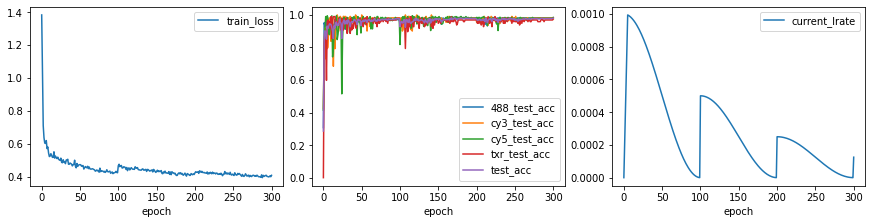

100%|█████████| 301/301 [1:32:12<00:00, 18.38s/it]

In [ ]:
# Train a pretrained ResNet-50:
experiment.run_experiment(**exps_resnet[3])

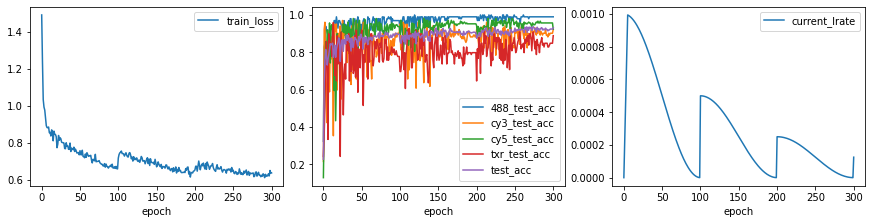

100%|█████████| 301/301 [1:37:51<00:00, 19.51s/it]

In [ ]:
# Run the experiment on heavily subsampled images using a pretrained ResNet 26:
experiment.run_experiment(**[e for e in exps_resnet_res if e['random_seed'] == 42 and e['train_width']==3][0])